<a href="https://colab.research.google.com/github/Avinash01715/ds-ml-projects/blob/main/Spam%20SMS%20detector/SpamClassifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Setup and Loading Data --> EDA --> Cleaning & Preprocessing --> Feature Engineering --> Modeling --> Threshold Analysis

In [167]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)
import warnings
warnings.filterwarnings('ignore')

**EDA (Exploratory Data Analysis)**

In [168]:
df = pd.read_csv('spam.csv', encoding='latin-1')
df.head()


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [169]:
df = df[['v1', 'v2']]
df.columns = ['label', 'message']
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [170]:
df['label'].value_counts()
df['message'].str.len().describe()

,message
count,5572.000000
mean,80.118808
std,59.690841
min,2.000000
25%,36.000000
50%,61.000000
75%,121.000000
max,910.000000


**Cleaning and Preprocessing**

In [171]:

print(df.isnull().sum())
print(df.duplicated().sum())
df.drop_duplicates(inplace=True)

label      0
message    0
dtype: int64
403


**Feature extraction and engineering**

In [172]:
# Encode target
df['label_num'] = (df['label'] == 'spam').astype(int)
df.head()

,label,message,label_num
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


In [173]:
df['msg_length'] = df['message'].apply(len)
df.head()

,label,message,label_num,msg_length
0,ham,"Go until jurong point, crazy.. Available only ...",0,111
1,ham,Ok lar... Joking wif u oni...,0,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1,155
3,ham,U dun say so early hor... U c already then say...,0,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",0,61


<Axes: xlabel='msg_length', ylabel='Count'>

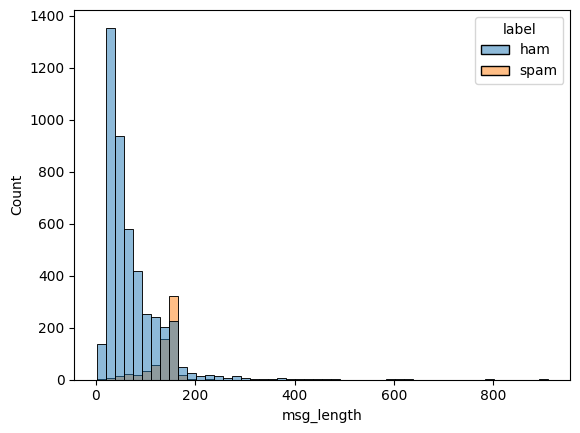

In [174]:
sns.histplot(data=df, x='msg_length', hue='label', bins=50)

**Modeling**

In [175]:
# Split
X_train, X_test, y_train, y_test = train_test_split(df['message'], df['label_num'], test_size=0.2,random_state=42, stratify=df['label_num'])

In [176]:
#TF-IDF vectorize the text
vectorizer = TfidfVectorizer(max_features=3000, stop_words='english')
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [177]:
# Train
model = LogisticRegression(max_iter=1000)
model.fit(X_train_vec, y_train)

LogisticRegression(max_iter=1000)

**Prediction and default evaluation**

In [178]:
# Predict at default threshold
y_pred = model.predict(X_test_vec)
print(accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.9613152804642167
[[902   1]
 [ 39  92]]
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       903
           1       0.99      0.70      0.82       131

    accuracy                           0.96      1034
   macro avg       0.97      0.85      0.90      1034
weighted avg       0.96      0.96      0.96      1034



**Threshold Analysis**

In [179]:
# Get probabilities, not just predictions
probs = model.predict_proba(X_test_vec)[:, 1]
probs


array([0.01814749, 0.04268317, 0.05660462, ..., 0.86798029, 0.0510494 ,
       0.05083521])

In [180]:
# Sweep thresholds
for t in [0.3, 0.5, 0.7, 0.9]:
    preds = (probs >= t).astype(int)
    p = precision_score(y_test, preds)
    r = recall_score(y_test, preds)
    cm = confusion_matrix(y_test, preds)
    print(f"Threshold={t}: Precision={p:.3f} Recall={r:.3f} | FP={cm[0,1]} FN={cm[1,0]}")

Threshold=0.3: Precision=0.949 Recall=0.847 | FP=6 FN=20
Threshold=0.5: Precision=0.989 Recall=0.702 | FP=1 FN=39
Threshold=0.7: Precision=1.000 Recall=0.435 | FP=0 FN=74
Threshold=0.9: Precision=1.000 Recall=0.084 | FP=0 FN=120


In [181]:
# Pull REAL misclassified messages, don't skip this
X_test_reset = X_test.reset_index(drop=True)
y_test_reset = y_test.reset_index(drop=True)

preds_default = (probs >= 0.5).astype(int)
fp_mask = (preds_default == 1) & (y_test_reset.values == 0)
fn_mask = (preds_default == 0) & (y_test_reset.values == 1)

print("False positives (legit flagged as spam):")
print(X_test_reset[fp_mask].head())

print("\nFalse negatives (spam that slipped through):")
print(X_test_reset[fn_mask].head())

False positives (legit flagged as spam):
327    K k:) sms chat with me.
Name: message, dtype: object

False negatives (spam that slipped through):
79     Thanks for the Vote. Now sing along with the s...
95     Want explicit SEX in 30 secs? Ring 02073162414...
105    You will recieve your tone within the next 24h...
108    Todays Vodafone numbers ending with 4882 are s...
112    Send a logo 2 ur lover - 2 names joined by a h...
Name: message, dtype: object
